In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [2]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
ts = pd.read_csv('MOD-00678.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31T18:59:38Z,7.221,0.804,0.196,0.017,0.037,0.012,5.072,762.896,34.986,2.403,27.638,49.5,0.4
1,2025-12-31T18:58:38Z,6.655,0.625,0.113,0.030,0.016,0.020,5.619,752.810,37.115,2.402,25.989,49.1,0.3
2,2025-12-31T18:57:38Z,6.896,0.719,0.185,0.018,0.023,0.017,5.458,766.214,36.403,2.468,25.507,49.3,0.3
3,2025-12-31T18:56:38Z,7.017,0.791,0.154,0.019,0.026,0.011,5.314,760.254,36.735,2.467,25.968,49.6,0.3
4,2025-12-31T18:55:38Z,6.525,0.657,0.140,0.024,0.019,0.008,5.181,756.560,35.683,2.402,26.916,49.6,0.3


In [4]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31 18:59:38,7.221,0.804,0.196,0.017,0.037,0.012,5.072,762.896,34.986,2.403,27.638,49.5,0.4
1,2025-12-31 18:58:38,6.655,0.625,0.113,0.030,0.016,0.020,5.619,752.810,37.115,2.402,25.989,49.1,0.3
2,2025-12-31 18:57:38,6.896,0.719,0.185,0.018,0.023,0.017,5.458,766.214,36.403,2.468,25.507,49.3,0.3
3,2025-12-31 18:56:38,7.017,0.791,0.154,0.019,0.026,0.011,5.314,760.254,36.735,2.467,25.968,49.6,0.3
4,2025-12-31 18:55:38,6.525,0.657,0.140,0.024,0.019,0.008,5.181,756.560,35.683,2.402,26.916,49.6,0.3


## Full Timeseries Plot

In [5]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-10-15,3.455149,0.337516,0.118358,0.027281,0.038788,0.031203,3.654705,722.984638,36.968056,2.129314,11.735630,53.980786,19.675478
2025-10-16,1.800193,0.199165,0.068220,0.014128,0.017962,0.012351,1.258244,725.122943,43.029028,1.896385,18.185029,39.611528,14.968611
2025-10-17,2.281223,0.290546,0.102258,0.021133,0.026234,0.016869,1.933663,750.417990,43.044547,1.881106,18.371822,36.505139,16.443472
2025-10-18,4.255208,0.475078,0.146609,0.029372,0.035899,0.024359,4.308538,835.905112,41.413300,1.979497,20.236315,41.822361,18.584444
2025-10-19,6.292894,0.987547,0.503859,0.172639,0.248803,0.242447,7.576337,814.295515,44.405431,2.040767,23.082110,66.952222,20.050486


In [6]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-10-15,3.455149,0.337516,0.118358,0.027281,0.038788,0.031203,3.654705,722.984638,36.968056,2.129314,11.735630,53.980786,19.675478,4.436297
2025-10-16,1.800193,0.199165,0.068220,0.014128,0.017962,0.012351,1.258244,725.122943,43.029028,1.896385,18.185029,39.611528,14.968611,3.401809
2025-10-17,2.281223,0.290546,0.102258,0.021133,0.026234,0.016869,1.933663,750.417990,43.044547,1.881106,18.371822,36.505139,16.443472,4.040092
2025-10-18,4.255208,0.475078,0.146609,0.029372,0.035899,0.024359,4.308538,835.905112,41.413300,1.979497,20.236315,41.822361,18.584444,5.307978
2025-10-19,6.292894,0.987547,0.503859,0.172639,0.248803,0.242447,7.576337,814.295515,44.405431,2.040767,23.082110,66.952222,20.050486,6.111750


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_707/3682742719.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)


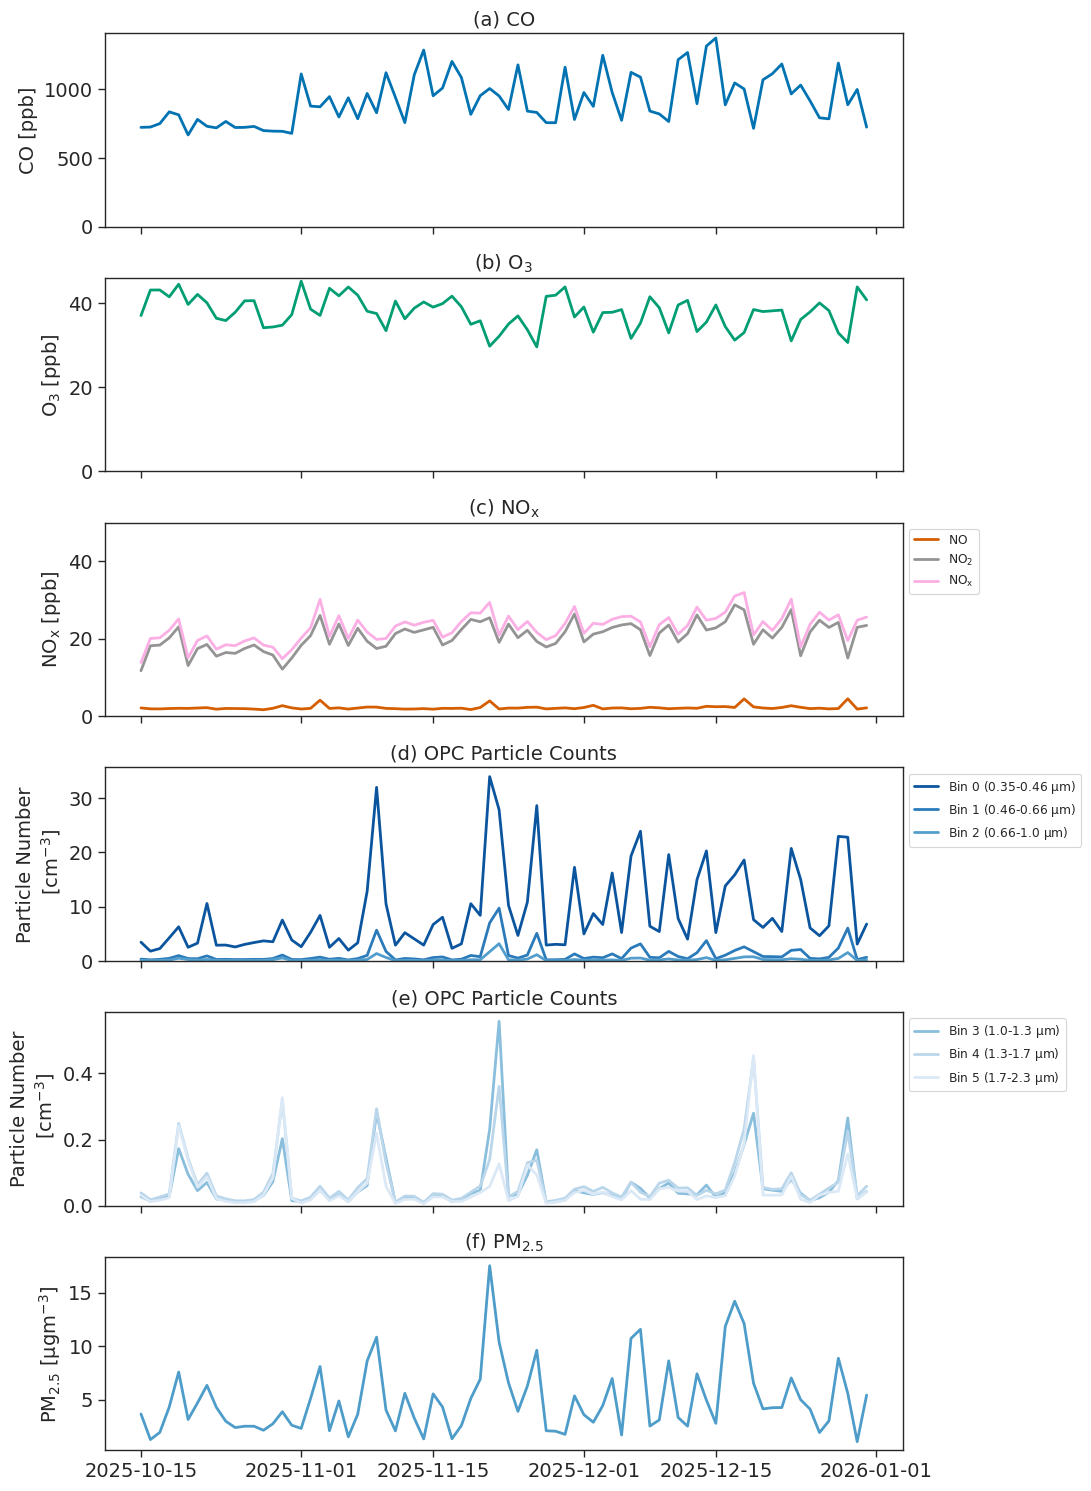

In [8]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

fig.savefig('timeseries_MOD-00678.png')

## Dirunal Plots

In [9]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-10-15 08:00:00,3.359857,0.338071,0.122381,0.029452,0.043452,0.039286,2.827619,790.275476,29.387805,1.833214,18.576286,76.438095,16.276190
2025-10-15 09:00:00,2.793700,0.327967,0.120683,0.027300,0.038483,0.036533,3.088717,774.241550,29.625467,2.241250,7.244150,62.893333,19.701667
2025-10-15 10:00:00,2.773450,0.316600,0.121433,0.029217,0.040217,0.036850,3.434833,759.313917,31.519133,2.442733,4.663767,52.495000,22.705000
2025-10-15 11:00:00,3.405250,0.357933,0.141367,0.031867,0.045050,0.035883,4.081383,682.758433,36.034517,2.449833,8.720133,50.328333,23.058333
2025-10-15 12:00:00,4.333667,0.381100,0.135517,0.031583,0.043450,0.033317,4.879867,675.327333,38.846133,2.411483,12.267350,47.665000,24.011667


In [10]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-10-15 08:00:00,3.359857,0.338071,0.122381,0.029452,0.043452,0.039286,2.827619,790.275476,29.387805,1.833214,18.576286,76.438095,16.276190,5.601954
2025-10-15 09:00:00,2.793700,0.327967,0.120683,0.027300,0.038483,0.036533,3.088717,774.241550,29.625467,2.241250,7.244150,62.893333,19.701667,5.525961
2025-10-15 10:00:00,2.773450,0.316600,0.121433,0.029217,0.040217,0.036850,3.434833,759.313917,31.519133,2.442733,4.663767,52.495000,22.705000,5.529710
2025-10-15 11:00:00,3.405250,0.357933,0.141367,0.031867,0.045050,0.035883,4.081383,682.758433,36.034517,2.449833,8.720133,50.328333,23.058333,5.688049
2025-10-15 12:00:00,4.333667,0.381100,0.135517,0.031583,0.043450,0.033317,4.879867,675.327333,38.846133,2.411483,12.267350,47.665000,24.011667,5.909744


In [11]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-10-15 08:00:00,3.359857,0.338071,0.122381,0.029452,0.043452,0.039286,2.827619,790.275476,29.387805,1.833214,18.576286,76.438095,16.276190,5.601954,8
2025-10-15 09:00:00,2.793700,0.327967,0.120683,0.027300,0.038483,0.036533,3.088717,774.241550,29.625467,2.241250,7.244150,62.893333,19.701667,5.525961,9
2025-10-15 10:00:00,2.773450,0.316600,0.121433,0.029217,0.040217,0.036850,3.434833,759.313917,31.519133,2.442733,4.663767,52.495000,22.705000,5.529710,10
2025-10-15 11:00:00,3.405250,0.357933,0.141367,0.031867,0.045050,0.035883,4.081383,682.758433,36.034517,2.449833,8.720133,50.328333,23.058333,5.688049,11
2025-10-15 12:00:00,4.333667,0.381100,0.135517,0.031583,0.043450,0.033317,4.879867,675.327333,38.846133,2.411483,12.267350,47.665000,24.011667,5.909744,12


In [12]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,10.104979,1.743970,0.487270,0.098014,0.098649,0.064192,5.112748,857.455877,37.192588,2.066900,22.404541,58.773772,7.052719,5.397806
01:00,10.028742,1.506621,0.365437,0.064497,0.066543,0.049373,4.935153,883.243338,36.904281,2.194684,22.274667,59.776875,6.726524,5.352647
02:00,9.568732,1.293987,0.320586,0.058911,0.062949,0.048338,4.609009,878.972871,36.826122,2.307498,22.046644,60.678618,6.486294,5.265086
03:00,9.529103,1.235861,0.316461,0.061507,0.066694,0.051082,4.475807,867.491369,36.382680,2.071172,21.781844,61.477686,6.250976,5.232804
04:00,9.697025,1.339452,0.337115,0.064202,0.067118,0.048782,4.389473,904.924392,35.883141,2.074871,22.242605,62.164505,6.040314,5.213027
05:00,10.003752,1.457620,0.362870,0.068288,0.068404,0.048506,4.452314,974.438642,35.033967,2.107297,23.234821,62.997259,5.914298,5.245439
06:00,10.079397,1.356670,0.348584,0.070540,0.075874,0.059272,4.742473,1023.599223,34.033398,2.257704,23.930961,63.658804,5.770011,5.340569
07:00,9.919011,1.312618,0.354978,0.073461,0.083190,0.066874,4.842702,1014.699975,33.913669,2.651232,23.710531,61.940461,6.387303,5.360061
08:00,9.550777,1.231815,0.332128,0.066734,0.075366,0.058939,5.331413,987.520537,34.182592,2.837858,20.826146,55.343092,8.851942,5.470592


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_707/2390676921.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_707/2390676921.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r

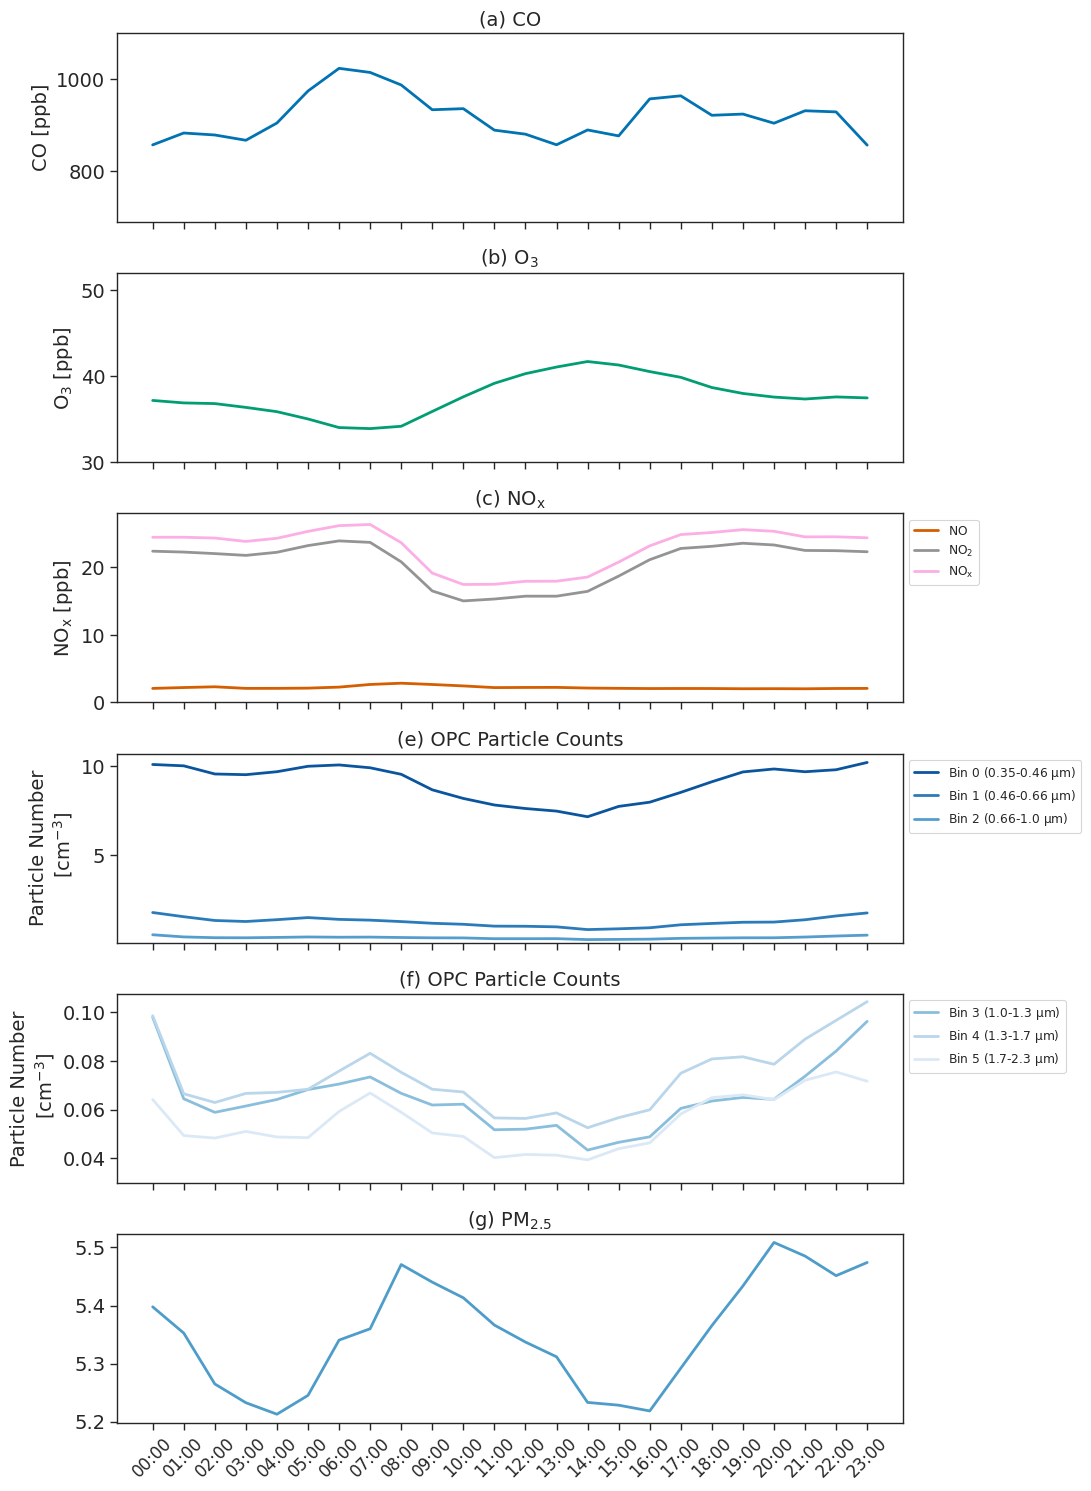

In [16]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 1100)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 28)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.03, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

fig.savefig('dirunal_MOD-00678_allfeatures.png')

## Diurnal by Season

In [17]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [18]:
ts_hour = ts_hour.reset_index()

In [19]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-10-15 08:00:00,3.359857,0.338071,0.122381,0.029452,0.043452,0.039286,2.827619,790.275476,29.387805,1.833214,18.576286,76.438095,16.276190,5.601954,8,Autumn
1,2025-10-15 09:00:00,2.793700,0.327967,0.120683,0.027300,0.038483,0.036533,3.088717,774.241550,29.625467,2.241250,7.244150,62.893333,19.701667,5.525961,9,Autumn
2,2025-10-15 10:00:00,2.773450,0.316600,0.121433,0.029217,0.040217,0.036850,3.434833,759.313917,31.519133,2.442733,4.663767,52.495000,22.705000,5.529710,10,Autumn
3,2025-10-15 11:00:00,3.405250,0.357933,0.141367,0.031867,0.045050,0.035883,4.081383,682.758433,36.034517,2.449833,8.720133,50.328333,23.058333,5.688049,11,Autumn
4,2025-10-15 12:00:00,4.333667,0.381100,0.135517,0.031583,0.043450,0.033317,4.879867,675.327333,38.846133,2.411483,12.267350,47.665000,24.011667,5.909744,12,Autumn


In [20]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      6.965346  1.433211  0.527293  0.116859  0.112082  0.064964   
       1      7.075783  1.104002  0.342406  0.066954  0.067700  0.049494   
       2      7.284190  1.029843  0.319203  0.063910  0.066534  0.050527   
       3      7.712129  1.068880  0.329306  0.068343  0.070493  0.053345   
       4      8.311680  1.323307  0.382832  0.073391  0.069300  0.045113   
       5      8.993463  1.521081  0.416715  0.075668  0.064927  0.038584   
       6      9.402453  1.389890  0.383593  0.073667  0.065967  0.040795   
       7      9.260200  1.261918  0.364059  0.071934  0.068643  0.044787   
       8      8.732790  1.135991  0.322708  0.064628  0.067053  0.046132   
       9      7.569653  1.033406  0.304968  0.061284  0.064617  0.045378   
       10     6.402829  0.872841  0.260321  0.054189  0.057790  0.041780   
       11     6.160288  0.845365  0.235564  0.047624  0.053663  0.040109   
       12     6.010768  0.820161  0.226947  0.047069  0.055908  0.044921   
       13     5.736956  0.721026  0.208144  0.044543  0.054267  0.042765   
       14     5.731232  0.695670  0.200142  0.041517  0.051454  0.040276   
       15     6.220125  0.762341  0.216966  0.045507  0.056027  0.045090   
       16     6.381869  0.796108  0.223517  0.045310  0.054359  0.043683   
       17     7.309895  0.999852  0.275364  0.056395  0.065573  0.050092   
       18     8.237968  1.098782  0.299289  0.062387  0.076955  0.063675   
       19     8.532254  1.127250  0.316178  0.066776  0.082700  0.069798   
       20     8.770936  1.129841  0.322828  0.068451  0.083915  0.071299   
       21     8.374374  1.260723  0.360281  0.074965  0.088682  0.074347   
       22     7.925287  1.433903  0.424696  0.085087  0.093945  0.075226   
       23     7.262146  1.280918  0.424032  0.091854  0.098379  0.067580   
Winter 0     14.662512  2.195073  0.429172  0.070659  0.079148  0.063073   
       1     14.315294  2.091068  0.398870  0.060932  0.064865  0.049197   
       2     12.885003  1.677422  0.322594  0.051655  0.057744  0.045160   
       3     12.166647  1.478253  0.297816  0.051585  0.061179  0.047797   
       4     11.708009  1.362889  0.270750  0.050863  0.063952  0.054108   
       5     11.470299  1.365499  0.284708  0.057575  0.073450  0.062908   
       6     11.083894  1.307375  0.296635  0.065898  0.090575  0.086689   
       7     10.875349  1.386214  0.341796  0.075678  0.104306  0.098937   
       8     10.764563  1.374006  0.346106  0.069860  0.087702  0.077943   
       9     10.312944  1.289928  0.327579  0.062862  0.074018  0.057934   
       10    10.834676  1.385365  0.381696  0.074248  0.081373  0.059723   
       11    10.275631  1.165440  0.306008  0.057879  0.060999  0.040535   
       12    10.002644  1.185656  0.320251  0.059299  0.057137  0.036622   
       13    10.047924  1.248895  0.356059  0.066962  0.065205  0.039154   
       14     9.262872  0.905397  0.235698  0.046178  0.054265  0.038041   
       15     9.988824  0.915175  0.239046  0.048197  0.057749  0.042281   
       16    10.340226  1.010370  0.262686  0.054078  0.068265  0.050310   
       17    10.339584  1.126987  0.301138  0.066700  0.088962  0.070328   
       18    10.450798  1.167449  0.304419  0.065316  0.086673  0.066837   
       19    11.449606  1.295973  0.315648  0.062388  0.080309  0.060477   
       20    11.507859  1.318694  0.307230  0.057800  0.070660  0.053100   
       21    11.720243  1.448615  0.356101  0.071913  0.089481  0.068648   
       22    12.696278  1.727906  0.403208  0.082604  0.101027  0.075963   
       23    14.756381  2.394099  0.529353  0.103212  0.113709  0.078058   

                 pm25           co         o3        no        no2         rh  \
Season Hour                                                                     
Autumn 0     4.527517   802.304439  38.377107  1.950949

In [21]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,6.965346,1.433211,0.527293,0.116859,0.112082,0.064964,4.527517,802.304439,38.377107,1.950949,21.340967,57.616259,10.671037,5.376542
1,Autumn,1,7.075783,1.104002,0.342406,0.066954,0.067700,0.049494,4.401104,810.871696,38.016429,2.134315,21.663765,58.894944,10.240056,5.348010
2,Autumn,2,7.284190,1.029843,0.319203,0.063910,0.066534,0.050527,4.318435,817.065540,37.632628,2.340840,21.577858,60.149815,9.912667,5.337123
3,Autumn,3,7.712129,1.068880,0.329306,0.068343,0.070493,0.053345,4.223848,798.053731,36.959886,2.004969,21.474991,61.510130,9.619648,5.326932
4,Autumn,4,8.311680,1.323307,0.382832,0.073391,0.069300,0.045113,4.147256,783.890442,36.372522,1.981130,21.985435,62.554423,9.370790,5.316728
5,Autumn,5,8.993463,1.521081,0.416715,0.075668,0.064927,0.038584,4.220982,886.523392,35.322937,2.038871,22.913754,63.572407,9.240852,5.356633
6,Autumn,6,9.402453,1.389890,0.383593,0.073667,0.065967,0.040795,4.464542,955.278398,33.807814,2.270052,23.836476,64.525644,9.002302,5.440164
7,Autumn,7,9.260200,1.261918,0.364059,0.071934,0.068643,0.044787,4.605074,922.586961,33.747162,2.647650,23.699632,62.160111,9.932185,5.471764
8,Autumn,8,8.732790,1.135991,0.322708,0.064628,0.067053,0.046132,5.019226,925.372859,34.149015,2.351432,19.354222,55.588075,12.397272,5.560707
9,Autumn,9,7.569653,1.033406,0.304968,0.061284,0.064617,0.045378,5.026894,878.933385,35.761900,2.543395,14.436865,48.497029,14.778333,5.511860


In [22]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [23]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,6.965346,1.433211,0.527293,0.116859,0.112082,0.064964,4.527517,802.304439,38.377107,1.950949,21.340967,57.616259,10.671037,5.376542
01:00,Autumn,1,7.075783,1.104002,0.342406,0.066954,0.067700,0.049494,4.401104,810.871696,38.016429,2.134315,21.663765,58.894944,10.240056,5.348010
02:00,Autumn,2,7.284190,1.029843,0.319203,0.063910,0.066534,0.050527,4.318435,817.065540,37.632628,2.340840,21.577858,60.149815,9.912667,5.337123
03:00,Autumn,3,7.712129,1.068880,0.329306,0.068343,0.070493,0.053345,4.223848,798.053731,36.959886,2.004969,21.474991,61.510130,9.619648,5.326932
04:00,Autumn,4,8.311680,1.323307,0.382832,0.073391,0.069300,0.045113,4.147256,783.890442,36.372522,1.981130,21.985435,62.554423,9.370790,5.316728
05:00,Autumn,5,8.993463,1.521081,0.416715,0.075668,0.064927,0.038584,4.220982,886.523392,35.322937,2.038871,22.913754,63.572407,9.240852,5.356633
06:00,Autumn,6,9.402453,1.389890,0.383593,0.073667,0.065967,0.040795,4.464542,955.278398,33.807814,2.270052,23.836476,64.525644,9.002302,5.440164
07:00,Autumn,7,9.260200,1.261918,0.364059,0.071934,0.068643,0.044787,4.605074,922.586961,33.747162,2.647650,23.699632,62.160111,9.932185,5.471764
08:00,Autumn,8,8.732790,1.135991,0.322708,0.064628,0.067053,0.046132,5.019226,925.372859,34.149015,2.351432,19.354222,55.588075,12.397272,5.560707
09:00,Autumn,9,7.569653,1.033406,0.304968,0.061284,0.064617,0.045378,5.026894,878.933385,35.761900,2.543395,14.436865,48.497029,14.778333,5.511860


In [24]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_707/2315705184.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_707/2315705184.py:41: SyntaxWarning: invalid escape sequence '\m'


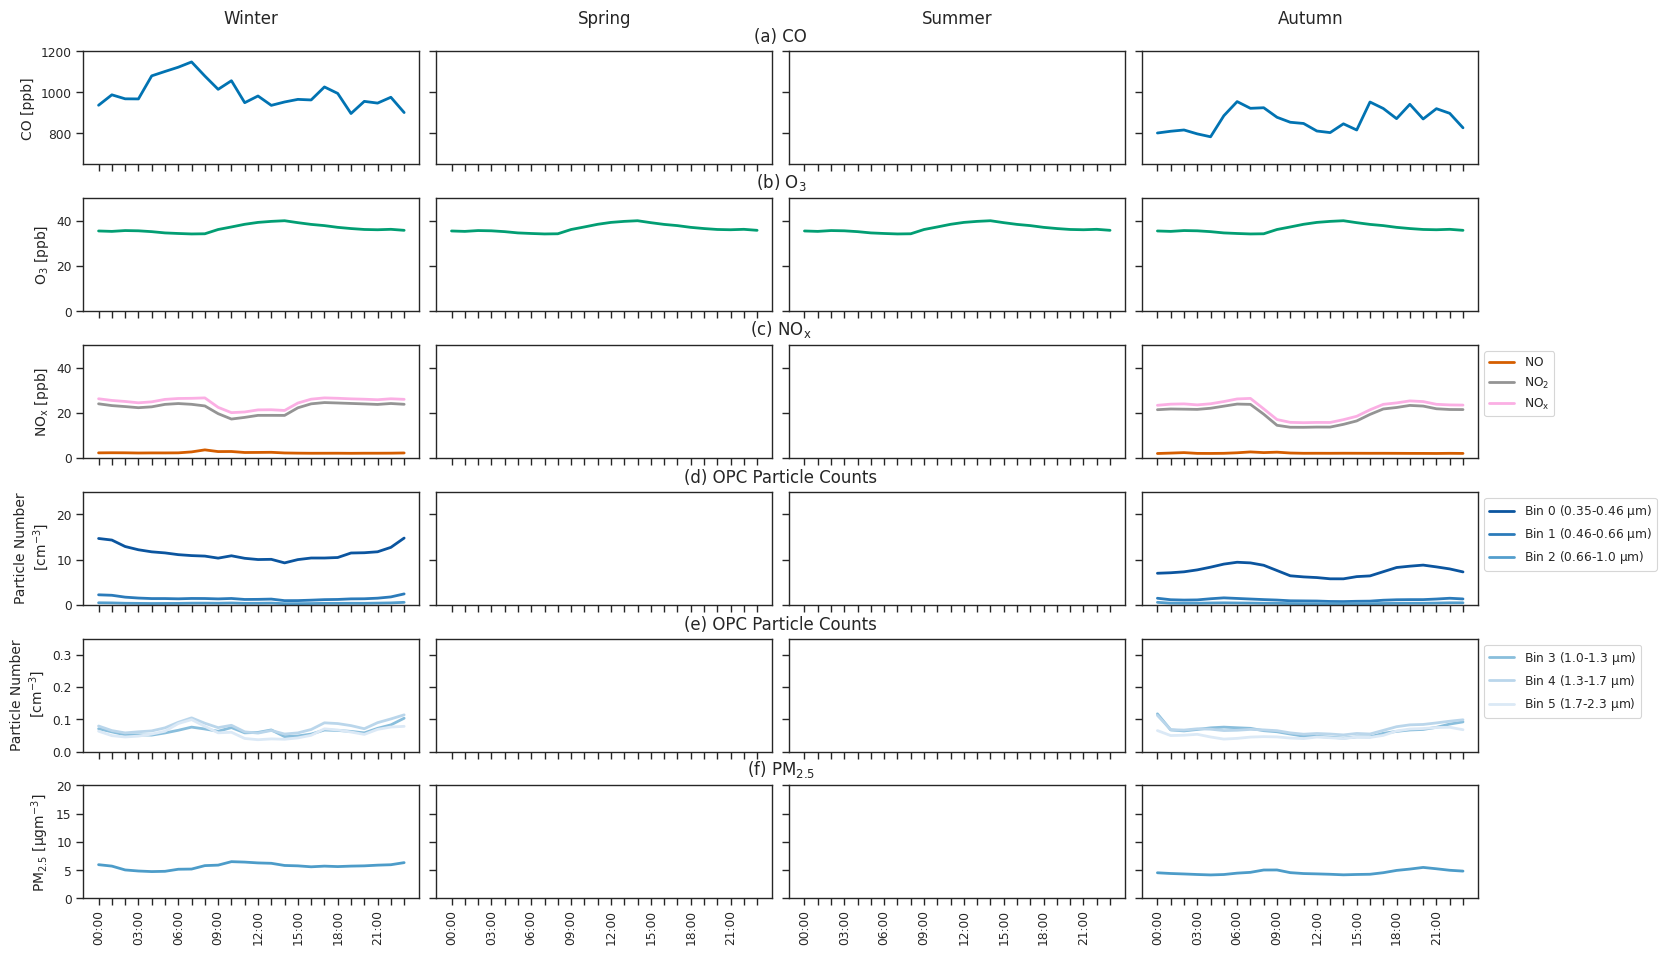

In [33]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 1200)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticks(range(24))
    ax[5,i].set_xticklabels(
    ['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''],
    rotation=90
)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

fig.savefig('diurnal_by_season_MOD-00678.png')